In [1]:
# CELL 1: SETUP & REPRODUCIBILITY
import os
import random
import re
import shutil
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import tifffile
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

def seed_everything(seed: int):
    """Ensures absolute reproducibility across all libraries."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print(f"Environment initialized. Using Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment initialized. Using Device: NVIDIA A100-SXM4-40GB


In [2]:
# CELL 2: CONFIGURATION
from dataclasses import dataclass

@dataclass(frozen=True)
class PipelineConfig:

    # Reproducibility
    seed: int = 42

    # Model Architecture
    input_dim: int = 1536
    output_dim: int = 1

    # Training Hyperparameters
    batch_size: int = 8192
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 50
    patience: int = 10 # For Early Stopping

    # Paths (Google Drive Sources)
    feature_set = "train"
    patch_size = 40

    CHANNELS = 3
    if CHANNELS == 3:
      CHANNEL_FOLDER = "3_channels_VV_VH_ratio"
    elif CHANNELS == 2:
      CHANNEL_FOLDER = "2_channels_VV_VH"
    else:
      raise ValueError("Invalid number of channels. Must be 2 or 3.")

    Output_folder = f"AS_LP_dense_EP{epochs}_BS{batch_size}_LR{str(learning_rate).split('.')[1]}_WD{str(weight_decay).split('.')[1]}_normLabels_seed{seed}"


    gdrive_parquet_dir: str = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/{CHANNEL_FOLDER}/Embedded_features/patch_size_{patch_size}/parquet"
    #gdrive_labels_tar: str = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/labels/train_agbm.tar.gz"
    gdrive_output_dir: str = os.path.join(f"/content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat", Output_folder)

    # Paths (Local NVMe Storage for Speed)
    local_data_dir: str = "/content/local_data"
    local_parquet_train: str = "/content/local_data/parquet/train"
    local_parquet_val: str = "/content/local_data/parquet/val"
    #local_labels_dir: str = "/content/local_data/labels"

config = PipelineConfig()
os.makedirs(config.gdrive_output_dir, exist_ok=True)

In [3]:
# CELL 3: ROBUST DATA TRANSFER TO LOCAL NVMe

def prep_local_storage(cfg: PipelineConfig):
    print("Preparing local NVMe storage...")
    os.makedirs(cfg.local_parquet_train, exist_ok=True)
    os.makedirs(cfg.local_parquet_val, exist_ok=True)

    files_to_copy = os.listdir(cfg.gdrive_parquet_dir)


    for file in tqdm(files_to_copy, desc="Verifying & Copying Parquet Shards"):
        src = os.path.join(cfg.gdrive_parquet_dir, file)

        # Determine destination
        if "train" in file:
            dest = os.path.join(cfg.local_parquet_train, file)
        elif "val" in file:
            dest = os.path.join(cfg.local_parquet_val, file)
        else:
            continue # Skip unrecognized files

        # The Check: Only copy if it doesn't already exist
        if not os.path.exists(dest):
            shutil.copy(src, dest)

    print("Data synchronization complete. Local storage is ready.")

prep_local_storage(config)

Preparing local NVMe storage...


Verifying & Copying Parquet Shards:   0%|          | 0/9 [00:00<?, ?it/s]

Data synchronization complete. Local storage is ready.


In [4]:
# CELL: PRO-TIER HIGH SPEED DATASET ENGINE
%%writefile fast_dataset.py
import os
# Prevent secret C++ thread spawning
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import gc
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import torch
from torch.utils.data import IterableDataset

# Force strict OS memory allocation
pa.set_memory_pool(pa.system_memory_pool())
pa.set_cpu_count(1)

class FastParquetDataset(IterableDataset):
    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):
        super().__init__()
        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith('.parquet')]
        self.batch_size = batch_size
        self.is_train = is_train

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is None:
            files = self.parquet_files.copy()
        else:
            files = self.parquet_files[worker_info.id::worker_info.num_workers]

        if self.is_train:
            random.shuffle(files)

        for file in files:
            # The Greedy, Blazing-Fast Reader
            pf = pq.ParquetFile(file)
            for batch in pf.iter_batches(batch_size=self.batch_size, columns=['features', 'label']):

                features = batch.column('features').flatten().to_numpy().reshape(-1, 1536).astype(np.float32)
                # Scale labels for perfect convergence
                labels = batch.column('label').to_numpy().astype(np.float32) / 400.0

                if self.is_train:
                    indices = np.random.permutation(len(features))
                    features = features[indices]
                    labels = labels[indices]

                yield torch.from_numpy(features), torch.from_numpy(labels).unsqueeze(1)

                del features, labels, batch

            del pf
            gc.collect()

Overwriting fast_dataset.py


In [5]:
"""# CELL: CREATE STANDALONE DATASET MODULE (FAST I/O + MEMORY SAFE)
%%writefile fast_dataset.py
import os

# 1. THE THREAD DEADLOCK FIX:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import gc
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq  # <-- Using the blazing fast raw Parquet API
import torch
from torch.utils.data import IterableDataset

# 2. Force PyArrow to use the OS memory allocator and single thread
pa.set_memory_pool(pa.system_memory_pool())
pa.set_cpu_count(1)

class FastParquetDataset(IterableDataset):
    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):
        super().__init__()
        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith('.parquet')]
        self.batch_size = batch_size
        self.is_train = is_train

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is None:
            files = self.parquet_files.copy()
        else:
            files = self.parquet_files[worker_info.id::worker_info.num_workers]

        if self.is_train:
            random.shuffle(files)

        for file in files:
            # 3. THE SPEED UP: Use raw ParquetFile iter_batches
            parquet_file = pq.ParquetFile(file)

            for batch in parquet_file.iter_batches(batch_size=self.batch_size, columns=['features', 'label']):

                # Use .copy() to ensure memory is released properly
                flat_features = batch.column('features').flatten().to_numpy().copy()
                features_matrix = flat_features.reshape(-1, 1536).astype(np.float32)

                # Target scaling
                labels = (batch.column('label').to_numpy().copy().astype(np.float32)) / 400.0

                del batch # Free the raw pyarrow batch immediately

                if self.is_train:
                    indices = np.random.permutation(len(features_matrix))
                    features_matrix = features_matrix[indices]
                    labels = labels[indices]

                yield torch.tensor(features_matrix), torch.tensor(labels).unsqueeze(1)

                del features_matrix, labels, flat_features

            del parquet_file
            gc.collect()

SyntaxError: incomplete input (750466718.py, line 1)

In [6]:
"""# CELL: CREATE STANDALONE DATASET MODULE (NORMALIZED)
%%writefile fast_dataset.py
import os
# Prevent C++ backend from spawning unauthorized threads
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import gc
import numpy as np
import pyarrow as pa
import pyarrow.dataset as ds
import torch
from torch.utils.data import IterableDataset

# Force immediate RAM release back to Linux OS
pa.set_cpu_count(1)
pa.set_memory_pool(pa.system_memory_pool())

class FastParquetDataset(IterableDataset):
    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):
        super().__init__()
        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith('.parquet')]
        self.batch_size = batch_size
        self.is_train = is_train

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is None:
            files = self.parquet_files.copy()
        else:
            files = self.parquet_files[worker_info.id::worker_info.num_workers]

        if self.is_train:
            random.shuffle(files)

        for file in files:
            dataset = ds.dataset(file, format="parquet")
            scanner = dataset.scanner(columns=['features', 'label'], batch_size=self.batch_size)

            for batch in scanner.to_batches():
                flat_features = batch.column('features').flatten().to_numpy().copy()
                features_matrix = flat_features.reshape(-1, 1536).astype(np.float32)

                # --- THE SCALING FIX ---
                # Scale labels down to [0.0, 1.0] for stable gradients
                labels = (batch.column('label').to_numpy().copy().astype(np.float32)) / 400.0

                del batch

                if self.is_train:
                    indices = np.random.permutation(len(features_matrix))
                    features_matrix = features_matrix[indices]
                    labels = labels[indices]

                yield torch.tensor(features_matrix), torch.tensor(labels).unsqueeze(1)
                del features_matrix, labels, flat_features

            del scanner, dataset
            gc.collect()

SyntaxError: incomplete input (832125548.py, line 1)

In [7]:
"""# CELL 3.5: CREATE STANDALONE DATASET MODULE (THREAD-SAFE & OOM-SAFE)
%%writefile fast_dataset.py
import os

# 1. THE THREAD DEADLOCK FIX:
# Force underlying C++ math libraries to use only 1 thread per worker.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import gc
import numpy as np
import pyarrow as pa
import pyarrow.dataset as ds
import torch
from torch.utils.data import IterableDataset

# 2. Force PyArrow to use the OS memory allocator (Fixes OOM leaks)
pa.set_memory_pool(pa.system_memory_pool())

# 3. THE THREAD DEADLOCK FIX:
# Force PyArrow to decompress using only 1 thread per worker process.
pa.set_cpu_count(1)

class FastParquetDataset(IterableDataset):
    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):
        super().__init__()
        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith('.parquet')]
        self.batch_size = batch_size
        self.is_train = is_train

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is None:
            files = self.parquet_files.copy()
        else:
            worker_id = worker_info.id
            num_workers = worker_info.num_workers
            files = self.parquet_files[worker_id::num_workers]

        if self.is_train:
            random.shuffle(files)

        for file in files:
            dataset = ds.dataset(file, format="parquet")
            scanner = dataset.scanner(columns=['features', 'label'], batch_size=self.batch_size)

            for batch in scanner.to_batches():

                flat_features = batch.column('features').flatten().to_numpy().copy()
                features_matrix = flat_features.reshape(-1, 1536)
                labels = (batch.column('label').to_numpy().copy().astype(np.float32)) / 400.0

                del batch

                if self.is_train:
                    indices = np.random.permutation(len(features_matrix))
                    features_matrix = features_matrix[indices]
                    labels = labels[indices]

                yield torch.tensor(features_matrix), torch.tensor(labels).unsqueeze(1)

                del features_matrix, labels, flat_features

            del scanner, dataset
            gc.collect()"""

'# CELL 3.5: CREATE STANDALONE DATASET MODULE (THREAD-SAFE & OOM-SAFE)\n%%writefile fast_dataset.py\nimport os\n\n# 1. THE THREAD DEADLOCK FIX:\n# Force underlying C++ math libraries to use only 1 thread per worker.\nos.environ["OMP_NUM_THREADS"] = "1"\nos.environ["MKL_NUM_THREADS"] = "1"\n\nimport random\nimport gc\nimport numpy as np\nimport pyarrow as pa\nimport pyarrow.dataset as ds\nimport torch\nfrom torch.utils.data import IterableDataset\n\n# 2. Force PyArrow to use the OS memory allocator (Fixes OOM leaks)\npa.set_memory_pool(pa.system_memory_pool())\n\n# 3. THE THREAD DEADLOCK FIX:\n# Force PyArrow to decompress using only 1 thread per worker process.\npa.set_cpu_count(1)\n\nclass FastParquetDataset(IterableDataset):\n    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):\n        super().__init__()\n        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith(\'.parquet\')]\n        self.batch_size = batch_size

In [8]:
"""# CELL 4: THE FAST DATASET PIPELINE
import os
import random
import numpy as np
import pyarrow.parquet as pq
import torch
from torch.utils.data import IterableDataset, DataLoader

class FastParquetDataset(IterableDataset):
    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):
        super().__init__()
        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith('.parquet')]
        self.batch_size = batch_size
        self.is_train = is_train

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is None:
            files = self.parquet_files.copy()
        else:
            files = self.parquet_files[worker_info.id::worker_info.num_workers]

        if self.is_train:
            random.shuffle(files)

        for file in files:
            parquet_file = pq.ParquetFile(file)
            for batch in parquet_file.iter_batches(batch_size=self.batch_size, columns=['features', 'label']):

                features_matrix = batch.column('features').flatten().to_numpy().reshape(-1, 1536).astype(np.float32)
                #labels = batch.column('label').to_numpy().astype(np.float32)
                labels = (batch.column('label').to_numpy().copy().astype(np.float32)) / 400.0

                if self.is_train:
                    indices = np.random.permutation(len(features_matrix))
                    features_matrix = features_matrix[indices]
                    labels = labels[indices]

                yield torch.tensor(features_matrix), torch.tensor(labels).unsqueeze(1)"""

"# CELL 4: THE FAST DATASET PIPELINE\nimport os\nimport random\nimport numpy as np\nimport pyarrow.parquet as pq\nimport torch\nfrom torch.utils.data import IterableDataset, DataLoader\n\nclass FastParquetDataset(IterableDataset):\n    def __init__(self, parquet_dir: str, batch_size: int, is_train: bool):\n        super().__init__()\n        self.parquet_files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith('.parquet')]\n        self.batch_size = batch_size\n        self.is_train = is_train\n\n    def __iter__(self):\n        worker_info = torch.utils.data.get_worker_info()\n        if worker_info is None:\n            files = self.parquet_files.copy()\n        else:\n            files = self.parquet_files[worker_info.id::worker_info.num_workers]\n\n        if self.is_train:\n            random.shuffle(files)\n\n        for file in files:\n            parquet_file = pq.ParquetFile(file)\n            for batch in parquet_file.iter_batches(batch_size=self.b

In [9]:
# CELL 5: MODEL & METRICS
class AnySatLinearProbe(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        # Linear Probing is strictly a single linear layer
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Optional: F.relu(self.linear(x)) if you want to force non-negative predictions.
        # Standard linear probing usually omits it, but AGB is non-negative.
        return self.linear(x)

def compute_metrics(preds: torch.Tensor, targets: torch.Tensor):
    """Computes standard regression metrics on GPU."""
    mse = F.mse_loss(preds, targets)
    rmse = torch.sqrt(mse)
    mae = torch.abs(preds - targets).mean()

    # R2 Score calculation
    ss_tot = torch.sum((targets - targets.mean()) ** 2)
    ss_res = torch.sum((targets - preds) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else torch.tensor(0.0, device=preds.device)

    return mse.item(), rmse.item(), mae.item(), r2.item()

In [ ]:
# CELL 6: A100 MAX THROUGHPUT TRAINING ENGINE
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import gc
import torch
import torch.multiprocessing as mp
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from fast_dataset import FastParquetDataset

# THE RAM EXPLOSION FIX: Force clean worker isolation
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

# --- 1. EPOCH FUNCTIONS ---
def run_train_epoch(epoch, config, model, optimizer, scaler, device):
    dataset = FastParquetDataset(config.local_parquet_train, config.batch_size, is_train=True)

    loader = DataLoader(
        dataset,
        batch_size=None,
        num_workers=10,         # Pro Tier: 6 Dedicated CPU Workers
        prefetch_factor=8,     # Keep GPU fed constantly
        pin_memory=True,       # Fast VRAM transfers
        persistent_workers=False
    )

    model.train()
    mse_accum, batches = 0.0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Train]")

    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            preds = model(features)
            loss = F.mse_loss(preds, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        mse_accum += loss.item()
        batches += 1
        pbar.set_postfix({"MSE": f"{loss.item():.4f}"})

    return mse_accum / max(1, batches)

def run_val_epoch(epoch, config, model, device):
    dataset = FastParquetDataset(config.local_parquet_val, config.batch_size, is_train=False)

    loader = DataLoader(
        dataset,
        batch_size=None,
        num_workers=10,
        prefetch_factor=8,
        pin_memory=True,
        persistent_workers=False
    )

    model.eval()
    mse_acc, rmse_acc, mae_acc, r2_acc, batches = 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Val]")
        for features, targets in pbar:
            features = features.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                preds = model(features)

            preds_fp32 = preds.float()
            targets_fp32 = targets.float()

            preds_real = preds_fp32 * 400.0
            targets_real = targets_fp32 * 400.0

            mse, rmse, mae, r2 = compute_metrics(preds_real, targets_real)
            mse_acc += mse; rmse_acc += rmse; mae_acc += mae; r2_acc += r2
            batches += 1

    return (mse_acc/batches, rmse_acc/batches, mae_acc/batches, r2_acc/batches)

# --- 2. SETUP & RESUME ---
torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AnySatLinearProbe(config.input_dim, config.output_dim).to(device)
model = torch.compile(model)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay, fused=True)
scaler = torch.amp.GradScaler('cuda')

checkpoint_path = os.path.join(config.gdrive_output_dir, "latest_checkpoint.pth")
start_epoch, best_val_mse, patience_counter = 1, float('inf'), 0
history = {"epoch": [], "train_mse": [], "val_mse": [], "val_rmse": [], "val_mae": [], "val_r2": []}

if os.path.exists(checkpoint_path):
    print(f"Resuming from checkpoint at {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_mse, patience_counter = checkpoint['best_val_mse'], checkpoint['patience_counter']
    history = checkpoint['history']
    print(f"Resuming from Epoch {start_epoch}")
else:
    print("No checkpoint found. Starting fresh training run.")

# --- 3. MAIN LOOP ---
for epoch in range(start_epoch, config.epochs + 1):

    avg_train_mse = run_train_epoch(epoch, config, model, optimizer, scaler, device)
    avg_val_mse, avg_val_rmse, avg_val_mae, avg_val_r2 = run_val_epoch(epoch, config, model, device)

    print(f"Epoch {epoch} Summary: Train MSE (Norm): {avg_train_mse:.4f} | Val MSE (Real): {avg_val_mse:.4f} | Val R2: {avg_val_r2:.4f}")

    history["epoch"].append(epoch)
    history["train_mse"].append(avg_train_mse)
    history["val_mse"].append(avg_val_mse); history["val_rmse"].append(avg_val_rmse)
    history["val_mae"].append(avg_val_mae); history["val_r2"].append(avg_val_r2)

    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'scaler_state_dict': scaler.state_dict(),
        'best_val_mse': best_val_mse, 'patience_counter': patience_counter, 'history': history
    }, checkpoint_path)

    if avg_val_mse < best_val_mse:
        best_val_mse = avg_val_mse
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(config.gdrive_output_dir, "best_model.pth"))

    else:
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{config.patience}")
        if patience_counter >= config.patience:
            print("Early stopping triggered!")
            break

    gc.collect()
    torch.cuda.empty_cache()

Resuming from checkpoint at /content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat/AS_LP_dense_EP50_BS8192_LR001_WD0001_normLabels_seed42/latest_checkpoint.pth...
Resuming from Epoch 2


Epoch 2/50 [Train]: 0it [00:00, ?it/s]

Epoch 2/50 [Val]: 0it [00:00, ?it/s]

Epoch 2 Summary: Train MSE (Norm): 0.0537 | Val MSE (Real): 8286.4067 | Val R2: 0.1373


Epoch 3/50 [Train]: 0it [00:00, ?it/s]

...

Epoch 4/50 [Train]: 0it [00:00, ?it/s]

Epoch 4/50 [Val]: 0it [00:00, ?it/s]

Epoch 4 Summary: Train MSE (Norm): 0.0533 | Val MSE (Real): 8274.2840 | Val R2: 0.1381


Epoch 5/50 [Train]: 0it [00:00, ?it/s]

Epoch 5/50 [Val]: 0it [00:00, ?it/s]

In [6]:
# CELL 6: HIGH-SPEED A100 TRAINING ENGINE
import os
# THESE MUST RUN BEFORE DATA LOADING STARTS
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import gc
import torch
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from fast_dataset import FastParquetDataset

# --- 1. EPOCH FUNCTIONS ---
def run_train_epoch(epoch, config, model, optimizer, scaler, device):
    dataset = FastParquetDataset(config.local_parquet_train, config.batch_size, is_train=True)

    # CRANKING THE SPEED BACK UP
    loader = DataLoader(
        dataset,
        batch_size=None,
        num_workers=4,
        prefetch_factor=2,
        pin_memory=True
    )

    model.train()
    mse_accum, batches = 0.0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Train]")

    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            preds = model(features)
            loss = F.mse_loss(preds, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        mse_accum += loss.item()
        batches += 1
        pbar.set_postfix({"MSE": f"{loss.item():.4f}"})

    return mse_accum / max(1, batches)

def run_val_epoch(epoch, config, model, device):
    dataset = FastParquetDataset(config.local_parquet_val, config.batch_size, is_train=False)

    loader = DataLoader(
        dataset,
        batch_size=None,
        num_workers=4,
        prefetch_factor=2,
        pin_memory=True
    )

    model.eval()
    mse_acc, rmse_acc, mae_acc, r2_acc, batches = 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Val]")
        for features, targets in pbar:
            features = features.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                preds = model(features)

            preds_fp32 = preds.float()
            targets_fp32 = targets.float()

            preds_real = preds_fp32 * 400.0
            targets_real = targets_fp32 * 400.0

            mse, rmse, mae, r2 = compute_metrics(preds_real, targets_real)
            mse_acc += mse; rmse_acc += rmse; mae_acc += mae; r2_acc += r2
            batches += 1

    return (mse_acc/batches, rmse_acc/batches, mae_acc/batches, r2_acc/batches)

# --- 2. SETUP & RESUME ---
torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AnySatLinearProbe(config.input_dim, config.output_dim).to(device)
model = torch.compile(model)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay, fused=True)
scaler = torch.amp.GradScaler('cuda')

checkpoint_path = os.path.join(config.gdrive_output_dir, "latest_checkpoint.pth")
start_epoch, best_val_mse, patience_counter = 1, float('inf'), 0
history = {"epoch": [], "train_mse": [], "val_mse": [], "val_rmse": [], "val_mae": [], "val_r2": []}

if os.path.exists(checkpoint_path):
    print(f"Resuming from checkpoint at {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_mse, patience_counter = checkpoint['best_val_mse'], checkpoint['patience_counter']
    history = checkpoint['history']
    print(f"Resuming from Epoch {start_epoch} (Previous Best Val MSE: {best_val_mse:.4f})")
else:
    print("No checkpoint found. Starting fresh training run.")

# --- 3. MAIN LOOP ---
for epoch in range(start_epoch, config.epochs + 1):

    avg_train_mse = run_train_epoch(epoch, config, model, optimizer, scaler, device)
    avg_val_mse, avg_val_rmse, avg_val_mae, avg_val_r2 = run_val_epoch(epoch, config, model, device)

    print(f"Epoch {epoch} Summary: Train MSE (Norm): {avg_train_mse:.4f} | Val MSE (Real): {avg_val_mse:.4f} | Val R2: {avg_val_r2:.4f}")

    history["epoch"].append(epoch)
    history["train_mse"].append(avg_train_mse)
    history["val_mse"].append(avg_val_mse); history["val_rmse"].append(avg_val_rmse)
    history["val_mae"].append(avg_val_mae); history["val_r2"].append(avg_val_r2)

    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'scaler_state_dict': scaler.state_dict(),
        'best_val_mse': best_val_mse, 'patience_counter': patience_counter, 'history': history
    }, checkpoint_path)

    if avg_val_mse < best_val_mse:
        best_val_mse = avg_val_mse
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(config.gdrive_output_dir, "best_model.pth"))

    else:
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{config.patience}")
        if patience_counter >= config.patience:
            print("Early stopping triggered!")
            break

    gc.collect()
    torch.cuda.empty_cache()

No checkpoint found. Starting fresh training run.


Epoch 1/50 [Train]: 0it [00:00, ?it/s]

RuntimeError: DataLoader worker (pid 25669) is killed by signal: Killed. 

In [9]:
# CELL 6: ISOLATED A100 TRAINING ENGINE (SCALED & FLOAT32-SAFE)
import os
import gc
import torch
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from fast_dataset import FastParquetDataset # Import the newly written module

# --- 1. EPOCH FUNCTIONS ---
def run_train_epoch(epoch, config, model, optimizer, scaler, device):
    dataset = FastParquetDataset(config.local_parquet_train, config.batch_size, is_train=True)
    loader = DataLoader(
        dataset, batch_size=None, num_workers=0,

    )

    model.train()
    mse_accum, batches = 0.0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Train]")

    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            preds = model(features)
            loss = F.mse_loss(preds, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        mse_accum += loss.item()
        batches += 1
        pbar.set_postfix({"MSE": f"{loss.item():.4f}"})

    return mse_accum / max(1, batches)

def run_val_epoch(epoch, config, model, device):
    dataset = FastParquetDataset(config.local_parquet_val, config.batch_size, is_train=False)
    loader = DataLoader(
        dataset, batch_size=None, num_workers=0,

    )

    model.eval()
    mse_acc, rmse_acc, mae_acc, r2_acc, batches = 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Val]")
        for features, targets in pbar:
            features = features.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                preds = model(features)

            # THE OVERFLOW FIX: Cast back to float32 before large math
            preds_fp32 = preds.float()
            targets_fp32 = targets.float()

            # Scale back up to real-world Biomass values for human-readable metrics
            preds_real = preds_fp32 * 400.0
            targets_real = targets_fp32 * 400.0

            mse, rmse, mae, r2 = compute_metrics(preds_real, targets_real)
            mse_acc += mse; rmse_acc += rmse; mae_acc += mae; r2_acc += r2
            batches += 1

    return (mse_acc/batches, rmse_acc/batches, mae_acc/batches, r2_acc/batches)

# --- 2. SETUP & RESUME ---
torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AnySatLinearProbe(config.input_dim, config.output_dim).to(device)
model = torch.compile(model)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay, fused=True)
scaler = torch.amp.GradScaler('cuda')

checkpoint_path = os.path.join(config.gdrive_output_dir, "latest_checkpoint.pth")
start_epoch, best_val_mse, patience_counter = 1, float('inf'), 0
history = {"epoch": [], "train_mse": [], "val_mse": [], "val_rmse": [], "val_mae": [], "val_r2": []}

if os.path.exists(checkpoint_path):
    print(f"Resuming from checkpoint at {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_mse, patience_counter = checkpoint['best_val_mse'], checkpoint['patience_counter']
    history = checkpoint['history']
    print(f"Resuming from Epoch {start_epoch} (Previous Best Val MSE: {best_val_mse:.4f})")
else:
    print("No checkpoint found. Starting fresh training run.")

# --- 3. MAIN LOOP ---
for epoch in range(start_epoch, config.epochs + 1):

    # Run the isolated functions. Memory is strictly allocated, used, and then destroyed.
    avg_train_mse = run_train_epoch(epoch, config, model, optimizer, scaler, device)
    avg_val_mse, avg_val_rmse, avg_val_mae, avg_val_r2 = run_val_epoch(epoch, config, model, device)

    print(f"Epoch {epoch} Summary: Train MSE (Normalized): {avg_train_mse:.4f} | Val MSE (Real): {avg_val_mse:.4f} | Val R2: {avg_val_r2:.4f}")

    history["epoch"].append(epoch)
    history["train_mse"].append(avg_train_mse)
    history["val_mse"].append(avg_val_mse); history["val_rmse"].append(avg_val_rmse)
    history["val_mae"].append(avg_val_mae); history["val_r2"].append(avg_val_r2)

    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'scaler_state_dict': scaler.state_dict(),
        'best_val_mse': best_val_mse, 'patience_counter': patience_counter, 'history': history
    }, checkpoint_path)

    if avg_val_mse < best_val_mse:
        best_val_mse = avg_val_mse
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(config.gdrive_output_dir, "best_model.pth"))

        metrics_text = (
            f"Best Model Metrics (Achieved at Epoch {epoch})\n{'-'*45}\n"
            f"Train MSE (Norm) : {avg_train_mse:.4f}\nVal MSE (Real)   : {avg_val_mse:.4f}\n"
            f"Val RMSE (Real)  : {avg_val_rmse:.4f}\nVal MAE (Real)   : {avg_val_mae:.4f}\nVal R2           : {avg_val_r2:.4f}\n"
        )
        with open(os.path.join(config.gdrive_output_dir, "best_metrics.txt"), "w") as f:
            f.write(metrics_text)


    else:
        patience_counter += 1

        print(f"--> No improvement. Patience: {patience_counter}/{config.patience}")
        if patience_counter >= config.patience:
            print("Early stopping triggered!")
            break

    # Final OS-level wipe before the next epoch begins
    gc.collect()
    torch.cuda.empty_cache()

No checkpoint found. Starting fresh training run.


Epoch 1/50 [Train]: 0it [00:00, ?it/s]

KeyboardInterrupt: 

In [10]:

# CELL 6: ISOLATED A100 TRAINING ENGINE (SCALED & FLOAT32-SAFE)
import os
import gc
import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Import your newly written dataset
from fast_dataset import FastParquetDataset

# --- 1. EPOCH FUNCTIONS ---
def run_train_epoch(epoch, config, model, optimizer, scaler, device):
    dataset = FastParquetDataset(config.local_parquet_train, config.batch_size, is_train=True)
    loader = DataLoader(
        dataset, batch_size=None, num_workers=8, # Fast parallel reads
        prefetch_factor=4, pin_memory=True, persistent_workers=False
    )

    model.train()
    mse_accum, batches = 0.0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Train]")

    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            preds = model(features)
            loss = F.mse_loss(preds, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        mse_accum += loss.item()
        batches += 1
        pbar.set_postfix({"MSE": f"{loss.item():.4f}"})

    return mse_accum / max(1, batches)

def run_val_epoch(epoch, config, model, device):
    dataset = FastParquetDataset(config.local_parquet_val, config.batch_size, is_train=False)
    loader = DataLoader(
        dataset, batch_size=None, num_workers=8,
        prefetch_factor=4, pin_memory=True, persistent_workers=False
    )

    model.eval()
    mse_acc, rmse_acc, mae_acc, r2_acc, batches = 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{config.epochs} [Val]")
        for features, targets in pbar:
            features = features.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                preds = model(features)

            # THE OVERFLOW FIX: Cast back to float32 before doing large math
            preds_fp32 = preds.float()
            targets_fp32 = targets.float()

            # SCALE BACK UP to real-world Biomass values for human-readable metrics
            preds_real = preds_fp32 * 400.0
            targets_real = targets_fp32 * 400.0

            mse, rmse, mae, r2 = compute_metrics(preds_real, targets_real)
            mse_acc += mse; rmse_acc += rmse; mae_acc += mae; r2_acc += r2
            batches += 1

    return (mse_acc/batches, rmse_acc/batches, mae_acc/batches, r2_acc/batches)

# --- 2. SETUP & RESUME ---
torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AnySatLinearProbe(config.input_dim, config.output_dim).to(device)
model = torch.compile(model)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay, fused=True)
scaler = torch.amp.GradScaler('cuda')

checkpoint_path = os.path.join(config.gdrive_output_dir, "latest_checkpoint.pth")
start_epoch, best_val_mse, patience_counter = 1, float('inf'), 0
history = {"epoch": [], "train_mse": [], "val_mse": [], "val_rmse": [], "val_mae": [], "val_r2": []}

if os.path.exists(checkpoint_path):
    print(f"Resuming from checkpoint...")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_mse, patience_counter = checkpoint['best_val_mse'], checkpoint['patience_counter']
    history = checkpoint['history']
    print(f"Resuming from Epoch {start_epoch} (Previous Best Val MSE: {best_val_mse:.4f})")
else:
    print("No checkpoint found. Starting fresh training run.")

# --- 3. MAIN LOOP ---
for epoch in range(start_epoch, config.epochs + 1):

    # Isolate memory: runs the function, then destroys all internal variables
    avg_train_mse = run_train_epoch(epoch, config, model, optimizer, scaler, device)
    avg_val_mse, avg_val_rmse, avg_val_mae, avg_val_r2 = run_val_epoch(epoch, config, model, device)

    print(f"Epoch {epoch} Summary: Train MSE (Norm): {avg_train_mse:.4f} | Val MSE (Real): {avg_val_mse:.4f} | Val R2: {avg_val_r2:.4f}")

    history["epoch"].append(epoch)
    history["train_mse"].append(avg_train_mse)
    history["val_mse"].append(avg_val_mse); history["val_rmse"].append(avg_val_rmse)
    history["val_mae"].append(avg_val_mae); history["val_r2"].append(avg_val_r2)

    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'scaler_state_dict': scaler.state_dict(),
        'best_val_mse': best_val_mse, 'patience_counter': patience_counter, 'history': history
    }, checkpoint_path)

    if avg_val_mse < best_val_mse:
        best_val_mse = avg_val_mse
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(config.gdrive_output_dir, "best_model.pth"))

        metrics_text = (
            f"Best Model Metrics (Achieved at Epoch {epoch})\n{'-'*45}\n"
            f"Train MSE (Norm) : {avg_train_mse:.4f}\nVal MSE (Real)   : {avg_val_mse:.4f}\n"
            f"Val RMSE (Real)  : {avg_val_rmse:.4f}\nVal MAE (Real)   : {avg_val_mae:.4f}\nVal R2           : {avg_val_r2:.4f}\n"
        )
        with open(os.path.join(config.gdrive_output_dir, "best_metrics.txt"), "w") as f:
            f.write(metrics_text)

    else:
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{config.patience}")
        if patience_counter >= config.patience:
            print("Early stopping triggered!")
            break

    # Final OS-level RAM wipe before the next epoch begins
    gc.collect()
    torch.cuda.empty_cache()

No checkpoint found. Starting fresh training run.


Epoch 1/50 [Train]: 0it [00:00, ?it/s]

RuntimeError: DataLoader worker (pid(s) 18499) exited unexpectedly

In [ ]:

from google.colab import drive
from google.colab import runtime

print("🛑 Flushing the final Parquet shard to Google Drive...")
print("This should only take a minute or two. Do not close the notebook!")

# Blocks execution until the final background
 upload is 100% complete
drive.flush_and_unmount()
print("✅ Drive safely unmounted. All Parquet shards are securely in the cloud.")

print("🔌 Disconnecting runtime to save GPU compute resources...")
runtime.unassign()

In [ ]:
"""# CELL 6: A100-OPTIMIZED TRAINING ENGINE
import json
import os
import torch
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm

# 1. Maximize Matrix Multiplication Speed
torch.set_float32_matmul_precision('high')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AnySatLinearProbe(config.input_dim, config.output_dim).to(device)

# 2. PyTorch 2.x Compiler: Fuses the operations into a single hyper-fast kernel
print("Compiling model for A100 (this takes a few seconds on epoch 1)...")
model = torch.compile(model)

# 3. Fused Adam: Performs all optimizer updates in one single GPU step
optimizer = optim.Adam(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    fused=True # <-- Massive speedup for A100
)

# 4. Gradient Scaler for Mixed Precision
scaler = torch.amp.GradScaler('cuda')

# --- RESUME FROM CHECKPOINT LOGIC (Same as before) ---
checkpoint_path = os.path.join(config.gdrive_output_dir, "latest_checkpoint.pth")
start_epoch = 1
best_val_mse = float('inf')
patience_counter = 0
history = {"epoch": [], "train_mse": [], "val_mse": [], "val_rmse": [], "val_mae": [], "val_r2": []}

if os.path.exists(checkpoint_path):
    print(f"Resuming from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict']) # Load scaler state
    start_epoch = checkpoint['epoch'] + 1
    best_val_mse = checkpoint['best_val_mse']
    patience_counter = checkpoint['patience_counter']
    history = checkpoint['history']

# --- MAIN TRAINING LOOP ---
for epoch in range(start_epoch, config.epochs + 1):
    model.train()
    train_mse_accum = 0.0
    train_batches = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{config.epochs} [Train]")
    for features, targets in train_pbar:
        # features arrive as float16, targets as float32
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True) # slightly faster than standard zero_grad()

        # 5. Automatic Mixed Precision (AMP) Context
        with torch.amp.autocast('cuda', dtype=torch.float16):
            preds = model(features)
            loss = F.mse_loss(preds, targets)

        # Scale loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_mse_accum += loss.item()
        train_batches += 1
        train_pbar.set_postfix({"MSE": loss.item()})

    avg_train_mse = train_mse_accum / max(1, train_batches)

    # --- VALIDATION (Also using AMP) ---
    model.eval()
    val_mse_accum, val_rmse_accum, val_mae_accum, val_r2_accum = 0.0, 0.0, 0.0, 0.0
    val_batches = 0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{config.epochs} [Val]")
        for features, targets in val_pbar:
            features, targets = features.to(device), targets.to(device)

            with torch.amp.autocast('cuda', dtype=torch.float16):
                preds = model(features)

            mse, rmse, mae, r2 = compute_metrics(preds, targets)
            val_mse_accum += mse; val_rmse_accum += rmse; val_mae_accum += mae; val_r2_accum += r2
            val_batches += 1

    avg_val_mse = val_mse_accum / max(1, val_batches)
    avg_val_rmse = val_rmse_accum / max(1, val_batches)
    avg_val_mae = val_mae_accum / max(1, val_batches)
    avg_val_r2 = val_r2_accum / max(1, val_batches)

    # Logging

    history["epoch"].append(epoch)
    history["train_mse"].append(avg_train_mse)
    history["val_mse"].append(avg_val_mse)
    history["val_rmse"].append(avg_val_rmse)
    history["val_mae"].append(avg_val_mae)
    history["val_r2"].append(avg_val_r2)

    print(f"Epoch {epoch} Summary: Train MSE: {avg_train_mse:.4f} | Val MSE: {avg_val_mse:.4f} | Val R2: {avg_val_r2:.4f}")

    # --- SAVE LATEST CHECKPOINT ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(), # Don't forget the scaler!
        'best_val_mse': best_val_mse,
        'patience_counter': patience_counter,
        'history': history
    }, checkpoint_path)


   # --- EARLY STOPPING & BEST MODEL SAVING ---
    if avg_val_mse < best_val_mse:
        best_val_mse = avg_val_mse
        patience_counter = 0

        # 1. Save the best model weights
        torch.save(model.state_dict(), os.path.join(config.gdrive_output_dir, "best_model.pth"))

        # 2. Save the metrics as a cleanly formatted .txt file
        metrics_text = (
            f"Best Model Metrics (Achieved at Epoch {epoch})\n"
            f"{'-'*45}\n"
            f"Train MSE : {avg_train_mse:.4f}\n"
            f"Val MSE   : {avg_val_mse:.4f}\n"
            f"Val RMSE  : {avg_val_rmse:.4f}\n"
            f"Val MAE   : {avg_val_mae:.4f}\n"
            f"Val R2    : {avg_val_r2:.4f}\n"
        )

        txt_path = os.path.join(config.gdrive_output_dir, "best_metrics.txt")
        with open(txt_path, "w") as f:
            f.write(metrics_text)

        print(f"--> Saved new best model and metrics to GDrive (Val MSE: {best_val_mse:.4f})")
    else:
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{config.patience}")
        if patience_counter >= config.patience:
            print("Early stopping triggered!")
            break"""

Compiling model for A100 (this takes a few seconds on epoch 1)...
Resuming from checkpoint...


Epoch 27/50 [Train]: 0it [00:00, ?it/s]

RuntimeError: DataLoader worker (pid(s) 18690, 18692) exited unexpectedly

Saved history CSV to /content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat/AS_LP_dense_EP50_BS8192_LR001_WD0001_seed42/training_history.csv
Saved metrics plot to /content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat/AS_LP_dense_EP50_BS8192_LR001_WD0001_seed42/training_metrics.png


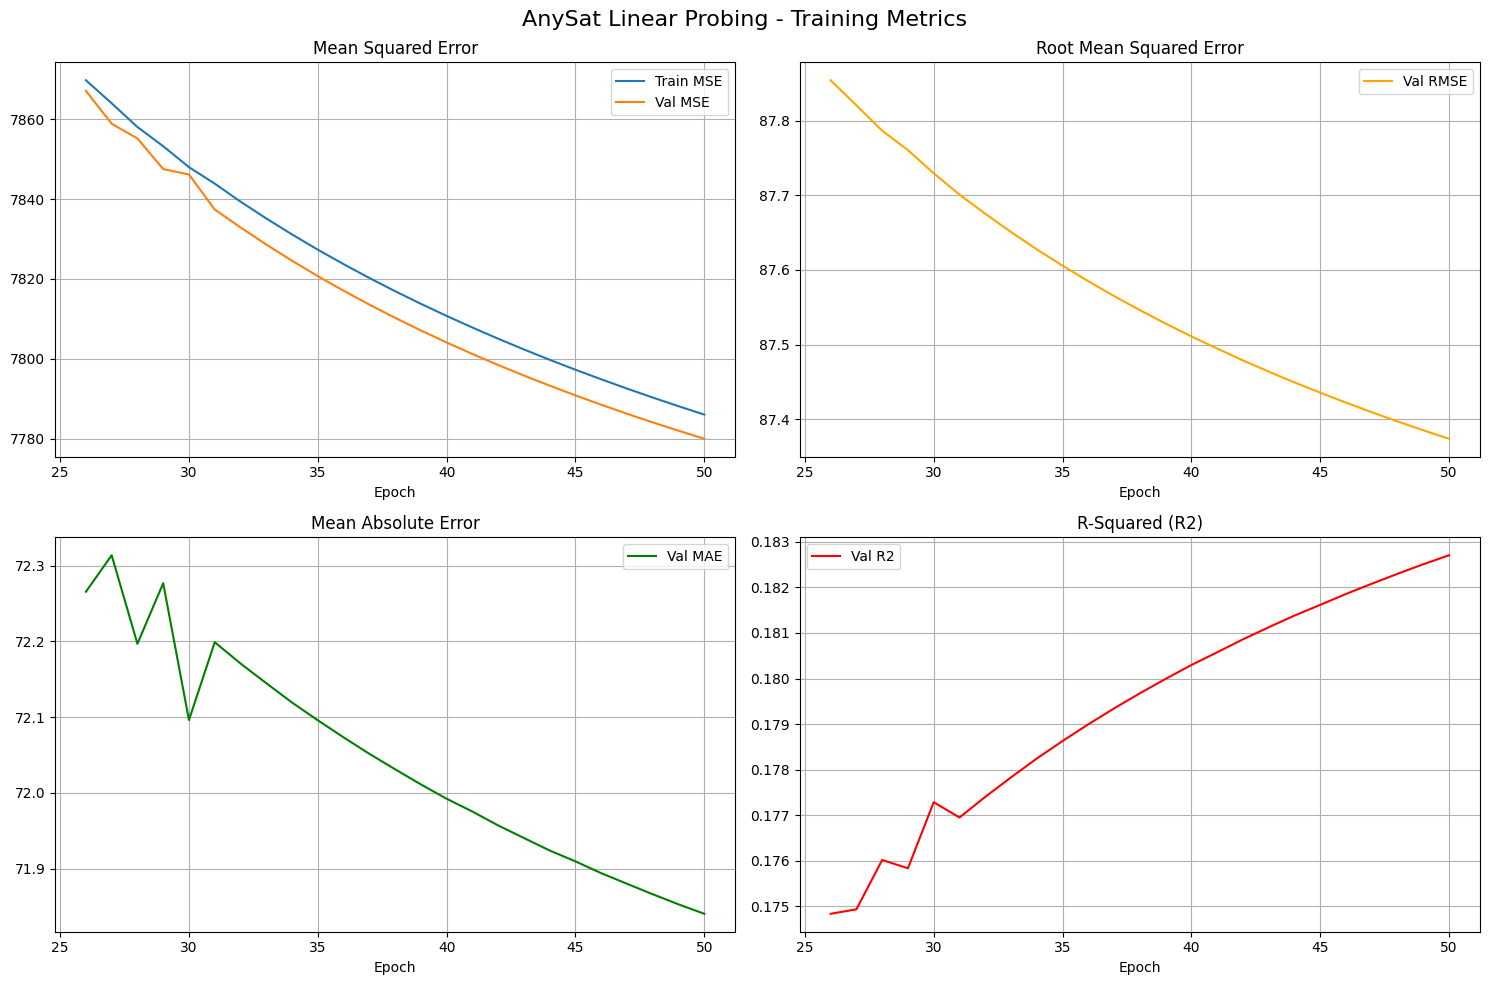

In [ ]:
# CELL 7: METRICS SAVING & VISUALIZATION
def plot_and_save_history(history: dict, output_dir: str):
    df_history = pd.DataFrame(history)

    # 1. Save CSV
    csv_path = os.path.join(output_dir, "training_history.csv")
    df_history.to_csv(csv_path, index=False)
    print(f"Saved history CSV to {csv_path}")

    # 2. Plot curves
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('AnySat Linear Probing - Training Metrics', fontsize=16)

    # MSE Plot
    axes[0, 0].plot(df_history['epoch'], df_history['train_mse'], label='Train MSE')
    axes[0, 0].plot(df_history['epoch'], df_history['val_mse'], label='Val MSE')
    axes[0, 0].set_title('Mean Squared Error')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # RMSE Plot
    axes[0, 1].plot(df_history['epoch'], df_history['val_rmse'], color='orange', label='Val RMSE')
    axes[0, 1].set_title('Root Mean Squared Error')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # MAE Plot
    axes[1, 0].plot(df_history['epoch'], df_history['val_mae'], color='green', label='Val MAE')
    axes[1, 0].set_title('Mean Absolute Error')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # R2 Plot
    axes[1, 1].plot(df_history['epoch'], df_history['val_r2'], color='red', label='Val R2')
    axes[1, 1].set_title('R-Squared (R2)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()

    # Save PNG
    png_path = os.path.join(output_dir, "training_metrics.png")
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f"Saved metrics plot to {png_path}")
    plt.show()

plot_and_save_history(history, config.gdrive_output_dir)

In [ ]:
# CELL 8: CLEANUP AND RUNTIME TERMINATION
import time
from google.colab import drive
from google.colab import runtime

def terminate_session():
    print("🎉 Pipeline execution completed successfully.")

    # 1. Force sync all pending writes to Google Drive
    print("Flushing data to Google Drive to prevent corruption...")
    drive.flush_and_unmount()
    print("Google Drive safely unmounted.")

    # 2. Safety buffer
    print("Initiating runtime deletion in 30 seconds to save GPU resources...")
    print("⚠️ WARNING: All unsaved local files in /content/ will be permanently lost!")

    # A brief pause gives you a window to interrupt the cell if you are
    # actively watching and decide you want to keep the session alive.
    time.sleep(30)

    # 3. Nuke the runtime
    print("Terminating runtime. Goodbye!")
    runtime.unassign()

# Execute the termination
terminate_session()

🎉 Pipeline execution completed successfully.
Flushing data to Google Drive to prevent corruption...
Google Drive safely unmounted.
Initiating runtime deletion in 30 seconds to save GPU resources...
⚠️ WARNING: All unsaved local files in /content/ will be permanently lost!
Terminating runtime. Goodbye!
